##### What we will be doing in this notebook (Problem Definition -> Data -> Evaluation -> Features -> Modeling -> Experiments):
- 1. Importing necessary libraries for data analysis, visualization, and machine learning. 
- 2. Problem definition and understanding the data.
- 3. Data cleaning and preprocessing.
- 4. Exploratory data analysis (EDA) and visualization.
- 5. Feature engineering and selection.
- 6. Model selection, training, and evaluation.
- 7. Experimentation with different algorithms and hyperparameter tuning.
- 8. Model interpretation and insights.
- 9. Conclusion and next steps. 

### 1. Importating necessary librairies for data analysis, visualization, an machine learning


In [2]:
# Importing necessary libraries for data analysis, visualization, and machine learning

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn as sk

print("Versions of the libraries used:")
print(sk.__version__ )
print(pd.__version__ )
print(sns.__version__ )
print(np.__version__ ) 

Versions of the libraries used:
1.9.0
3.0.3
0.13.2
2.4.6


### 2. Problem definition and data understanding

🎓 **AI Impact on Students — Academic & Well-being Dataset**

A comprehensive dataset capturing how Generative AI tool usage shapes student performance, skill development, mental health, and burnout risk across 50,000 students.

📌 *About the Dataset*

As Generative AI tools like ChatGPT, Copilot, Claude, and Gemini become deeply embedded in academic life, understanding their true impact on students has never been more critical. This dataset provides a rich, multi-dimensional snapshot of student interactions with AI — spanning academic outcomes, behavioral patterns, institutional context, and psychological well-being.

Whether you're a researcher, educator, data scientist, or policymaker, this dataset offers fertile ground for exploring the benefits and risks of AI adoption in higher education.





#### 📊 Dataset Overview

| Property         | Details                                                      |
| ---------------- | ------------------------------------------------------------ |
| Rows             | 50,000 students                                              |
| Columns          | 16 features                                                  |
| Missing Values   | None (fully complete dataset)                                |
| File Format      | CSV                                                          |
| Target Variables | Post_Semester_GPA, Skill_Retention_Score, Burnout_Risk_Level |

---

#### 🗂️ Column Descriptions

##### 🪪 Identifier

| Column     | Type    | Description                                                |
| ---------- | ------- | ---------------------------------------------------------- |
| Student_ID | Integer | Unique numeric identifier for each student (100001–150000) |

---

##### 🎓 Academic Profile

| Column            | Type        | Description                                                      |
| ----------------- | ----------- | ---------------------------------------------------------------- |
| Major_Category    | Categorical | Field of study (STEM, Business, Humanities, Medical, Arts)       |
| Year_of_Study     | Categorical | Academic level (Freshman, Sophomore, Junior, Senior, Graduate)   |
| Pre_Semester_GPA  | Float       | GPA at start of semester (~1.18 – 4.00)                          |
| Post_Semester_GPA | Float       | GPA at end of semester (~1.00 – 4.00) — primary outcome variable |

---

##### 🤖 AI Usage Behaviour

| Column                   | Type        | Description                                                                                                                      |
| ------------------------ | ----------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Weekly_GenAI_Hours       | Float       | Weekly hours using generative AI tools (0–40 hrs)                                                                                |
| Primary_Use_Case         | Categorical | Main AI usage purpose (Copywriting/Drafting, Summarizing/Reading, Debugging/Troubleshooting, Ideation, Direct Answer Generation) |
| Prompt_Engineering_Skill | Categorical | Self-rated prompt skill (Beginner, Intermediate, Advanced)                                                                       |
| Tool_Diversity           | Integer     | Number of AI tools used (1–5)                                                                                                    |
| Paid_Subscription        | Boolean     | Whether student has paid AI subscription (True/False)                                                                            |

---

##### 📚 Study Behaviour

| Column                  | Type    | Description                                   |
| ----------------------- | ------- | --------------------------------------------- |
| Traditional_Study_Hours | Float   | Weekly non-AI study hours (1–36 hrs)          |
| Perceived_AI_Dependency | Integer | Self-rated AI dependency (1 = low, 10 = high) |

---

##### 🏛️ Institutional Context

| Column               | Type        | Description                                                                |
| -------------------- | ----------- | -------------------------------------------------------------------------- |
| Institutional_Policy | Categorical | AI usage policy (Allowed_With_Citation, Strictly_Ban, Actively_Encouraged) |

---

##### 🧠 Mental Health & Well-being

| Column                     | Type        | Description                            |
| -------------------------- | ----------- | -------------------------------------- |
| Anxiety_Level_During_Exams | Integer     | Exam anxiety score (1–10)              |
| Skill_Retention_Score      | Float       | Skill retention after semester (0–100) |
| Burnout_Risk_Level         | Categorical | Burnout risk (Low, Medium, High)       |

---

#### 📈 Key Statistics

| Feature                 | Min   | Mean  | Max    |
| ----------------------- | ----- | ----- | ------ |
| Pre-Semester GPA        | 1.18  | 3.15  | 4.00   |
| Post-Semester GPA       | 1.00  | 3.35  | 4.00   |
| Weekly GenAI Hours      | 0.00  | 8.43  | 40.00  |
| Traditional Study Hours | 1.00  | 11.21 | 35.86  |
| Skill Retention Score   | 10.78 | 75.80 | 100.00 |
| Perceived AI Dependency | 1     | 3.51  | 10     |
| Anxiety Level           | 1     | 4.27  | 10     |

---

#### 💡 Potential Use Cases

* 📉 GPA Change Analysis — relationship between AI usage and academic performance
* 🧩 Burnout Prediction — classify Burnout_Risk_Level
* 🔍 Skill Retention Modelling — impact of AI reliance on learning retention
* 🏛️ Policy Impact Study — compare institutional AI policies
* 🧠 Mental Health Insights — link AI dependency, anxiety, burnout
* 🎓 Major & Year Trends — differences across disciplines
* ⚡ Prompt Skill Analysis — impact of prompt engineering skill on outcomes

---

#### 🔑 Suggested Target Variables

| Goal           | Target Column                                       |
| -------------- | --------------------------------------------------- |
| Regression     | Post_Semester_GPA, Skill_Retention_Score            |
| Classification | Burnout_Risk_Level                                  |
| Analysis       | Perceived_AI_Dependency, Anxiety_Level_During_Exams |

---

#### 📂 Feature Categories at a Glance

```
AI_Student_Impact_Dataset
├── 🪪 Identifier          → Student_ID
├── 🎓 Academic Profile    → Major_Category, Year_of_Study, Pre/Post GPA
├── 🤖 AI Behaviour        → Weekly_GenAI_Hours, Primary_Use_Case,
│                            Prompt_Engineering_Skill, Tool_Diversity,
│                            Paid_Subscription
├── 📚 Study Habits        → Traditional_Study_Hours, Perceived_AI_Dependency
├── 🏛️ Institutional       → Institutional_Policy
└── 🧠 Well-being          → Anxiety_Level_During_Exams,
                             Skill_Retention_Score,
                             Burnout_Risk_Level
```

---

#### 🧹 Data Quality

* ✅ No missing values across all 50,000 rows
* ✅ Consistent categorical encoding
* ✅ Balanced representation across majors and policies
* ✅ Ready for analysis (no preprocessing required)

---

#### 📜 License

Please check the dataset license before use. Ensure proper citation for academic or commercial use.

---

#### 🙏 Acknowledgements

If you use this dataset, consider sharing feedback or analysis results to support future improvements.

---

##### 🚀 Happy Analysing!


In [3]:
# Data loading and initial exploration

df = pd.read_csv('../kaggle-data/ai_student_impact_dataset.csv')
df.head()
df.shape # (rows, column)

(50000, 16)

In [32]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [33]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

#### 3. Data cleaning and preprocessing

- No need for data cleaning as the dataset is already clean and well-structured.

In [8]:
# Check if there are any missing values in the data
df.isna().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

#### 🔑 Suggested Target Variables

| Goal           | Target Column                                       |
| -------------- | --------------------------------------------------- |
| Regression     | Post_Semester_GPA, Skill_Retention_Score            |
| Classification | Burnout_Risk_Level                                  |
| Analysis       | Perceived_AI_Dependency, Anxiety_Level_During_Exams |


#### 4. Exploratory data analysis (EDA) and visualization

In [ ]:
# Let's find how many instances of each Burnout_Risk_Level (Low, Medium, High) we have in the dataset
df["Burnout_Risk_Level"].value_counts()

Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

As we can see, the burn out risk level is evaluated within 3 categories. Among 50000 students, 16369 have a low burn out risk level, with 21144 with a medium burn out risk level, and 12487 with a high burn out risk level.

<Axes: xlabel='Burnout_Risk_Level'>

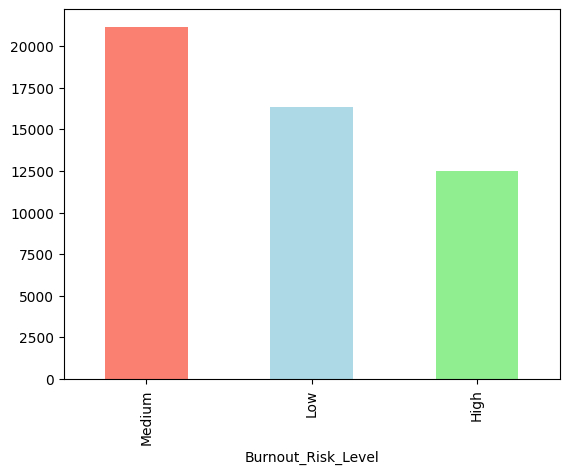

In [7]:
# Let's visualize the burn out risk level
df["Burnout_Risk_Level"].value_counts().plot(kind="bar", color=["salmon", "lightblue", "lightgreen"])

In [ ]:
# Let's find out how the values are distributed for each Perceived_AI_Dependency
df["Perceived_AI_Dependency"].value_counts()

Perceived_AI_Dependency
3     10478
4      9934
2      8874
1      7303
5      6745
6      3521
7      1722
8       855
9       378
10      190
Name: count, dtype: int64

<Axes: xlabel='Perceived_AI_Dependency'>

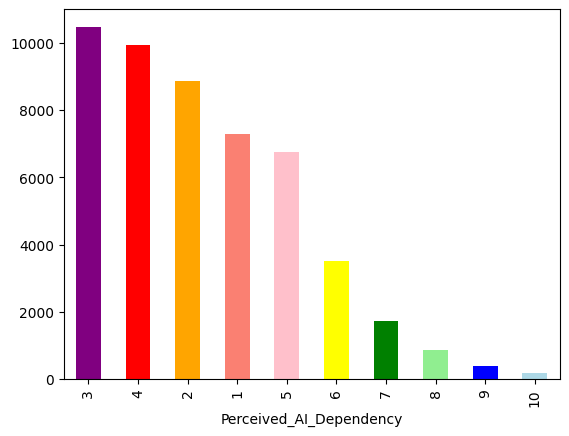

In [18]:
# Let's visualize the distribution of Perceived_AI_Dependency
df["Perceived_AI_Dependency"].value_counts().plot(kind="bar", color=["purple", "red", "orange", "salmon", "pink", "yellow", "green", "lightgreen", "blue", "lightblue"])

In [20]:
# Let's find out how the values are distributed for each Anxiety_Level_During_Exams
df["Anxiety_Level_During_Exams"].value_counts()

Anxiety_Level_During_Exams
4     8749
5     8222
3     7806
6     6107
2     5752
1     5655
7     3850
8     2088
9     1151
10     620
Name: count, dtype: int64

<Axes: xlabel='Anxiety_Level_During_Exams'>

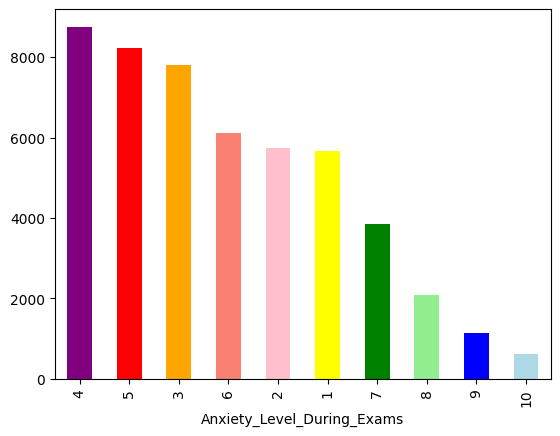

In [21]:
# Let's visualize the distribution of Anxiety_Level_During_Exams
df["Anxiety_Level_During_Exams"].value_counts().plot(kind="bar", color=["purple", "red", "orange", "salmon", "pink", "yellow", "green", "lightgreen", "blue", "lightblue"])

In [23]:
# Post_Semester_GPA
df["Post_Semester_GPA"].value_counts()

Post_Semester_GPA
4.000    4804
3.500      57
3.624      57
3.556      55
3.516      54
         ... 
2.045       1
1.732       1
1.923       1
1.874       1
1.715       1
Name: count, Length: 2269, dtype: int64